# RB 主力换约阈值与旧主力反超

本 Notebook 统计螺纹钢（XSGE.RB）：后月合约成交量刚超过旧主力时切换，之后有多少次旧合约成交量重新超过新合约。样本覆盖正式日线湖中 RB 的全部可用历史；每次运行输出实际日期范围。

**阈值含义：**1.00 表示新合约成交量严格大于旧合约成交量，即比值大于 1，并非“比旧合约多一倍”（比值大于 2）。对照阈值为 1.10，即严格超过旧合约的 110%。

**主力规则：**用信号日已收盘成交量决定下一交易日；初始化取成交量最大合约，并列依次看持仓量、较近退市日、合约代码。后续仅向更晚退市合约换约，不回退到更早到期合约。旧主力下一交易日不再存续，或信号日无有效正成交量时，按后月候选切换；这些强制换约单独报告，不混入成交量阈值事件。

主力选择对应 [testing_10.ipynb](testing_10.ipynb) 的 `build_main_contract_daily`。本实验把参数下界放宽到 1.00，保留其他选择分支。两种阈值分别从完整历史独立重建主力路径，不能把 1.10 的既有换约日直接改标签当成 1.00 的结果。

只读正式 silver，使用 `latitude_env_v2` 内核。结果保存在本 Notebook，图另存同目录；不调用行情 API，不改写既有主力映射或正式湖。

文件输出：图表和表格默认保留在 Notebook 内。`EXPORT_FILES = True` 时，独立图片统一保存到 `testing_13/`；默认运行不创建这些独立文件。

In [1]:
from __future__ import annotations

import math
import pathlib
import sys
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

from config.settings import settings
from config.data_contracts import (
    FUTURES_VARIETY_CALENDAR_SCHEMA, FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA, validate_arrow_table, arrow_to_pandas,
)
from R02_Market_Data.a01_Collection.b00_03_notebook_schema_browser import display_schema_metadata

EXCHANGE_CODE = "XSGE"
UNDERLYING_CODE = "RB"
ROLL_TRIGGER_RATIOS = (1.00, 1.10)
FOLLOWUP_WINDOWS = (1, 5, 10, 20)
notebook_dir = candidate_root / "R00_draft_collection_01"
output_dir = notebook_dir / "testing_13"
EXPORT_FILES = False  # 图表默认内嵌；需要独立文件时显式设为 True。
if EXPORT_FILES:
    output_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", 20)
print(f"解释器：{sys.executable}")
print(f"运行时间：{datetime.now(ZoneInfo('Asia/Shanghai')).isoformat(timespec='seconds')}")

解释器：E:\anaconda3\envs\latitude_env_v2\python.exe
运行时间：2026-10-04T04:10:59+08:00


## 1. 读取品种日历、合约日历和日线

三个输入的表名、主键和分区从权威 Schema metadata 读取；正式湖位置来自 `settings.futures_lake_root`。只读 XSGE.RB 数据。物理字段、类型、nullable 及表身份按契约检查，信任生产者对正式数据的业务验收。主力重建使用完整历史，末端限制为最后一个有有效日成交量的日期，避免未来日历形成虚假换约。

In [2]:
display_schema_metadata([
    FUTURES_VARIETY_CALENDAR_SCHEMA, FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
])

In [3]:
silver_inputs = {}
input_coverage_rows = []
for input_role, input_schema in [
    ("variety_calendar", FUTURES_VARIETY_CALENDAR_SCHEMA),
    ("contract_calendar", FUTURES_CONTRACT_CALENDAR_SCHEMA),
    ("daily", FUTURES_DAILY_SCHEMA),
]:
    input_table_name = input_schema.metadata[b"table_name"].decode("utf-8")
    input_primary_key = input_schema.metadata[b"primary_key"].decode("utf-8").split(",")
    input_partition_columns = input_schema.metadata[b"partition_columns"].decode("utf-8").split(",")
    input_filter = (
        (ds.field("exchange_code") == EXCHANGE_CODE)
        & (ds.field("underlying_code") == UNDERLYING_CODE)
    )
    input_dataset = ds.dataset(
        settings.futures_lake_root / "silver" / input_table_name,
        format="parquet", schema=input_schema,
        partitioning=ds.partitioning(
            pa.schema([input_schema.field(name) for name in input_partition_columns]),
            flavor="hive",
        ),
    )
    expected_fields = [field for field in input_schema if field.name not in input_partition_columns]
    fragment_count = 0
    for input_fragment in input_dataset.get_fragments(filter=input_filter):
        fragment_count += 1
        physical_schema = input_fragment.physical_schema
        physical_fields = [field for field in physical_schema if field.name not in input_partition_columns]
        if not pa.schema(physical_fields).equals(pa.schema(expected_fields), check_metadata=False):
            raise ValueError(f"输入物理结构不兼容：{input_fragment.path}")
        for name in input_partition_columns:
            if name in physical_schema.names and not physical_schema.field(name).equals(
                input_schema.field(name), check_metadata=False,
            ):
                raise ValueError(f"输入分区字段不兼容：{input_fragment.path} / {name}")
        for metadata_key in [b"table_name", b"primary_key", b"partition_columns", b"schema_version"]:
            if (physical_schema.metadata or {}).get(metadata_key) != input_schema.metadata[metadata_key]:
                raise ValueError(f"输入表身份或契约版本不兼容：{input_fragment.path}")
    input_table = input_dataset.to_table(filter=input_filter)
    validated_input_table = validate_arrow_table(input_table, input_schema)
    input_df = arrow_to_pandas(validated_input_table, input_schema)
    if input_df.empty:
        raise ValueError(f"{input_table_name} 没有 {EXCHANGE_CODE}.{UNDERLYING_CODE} 数据")
    silver_inputs[input_role] = input_df
    input_coverage_rows.append({
        "表": input_table_name, "行数": len(input_df),
        "首日": input_df["trading_date"].min(), "末日": input_df["trading_date"].max(),
        "物理分片数": fragment_count, "主键": ",".join(input_primary_key),
    })

variety_calendar_df = silver_inputs["variety_calendar"]
contract_calendar_df = silver_inputs["contract_calendar"]
daily_df = silver_inputs["daily"]
valid_volume_mask = daily_df["has_market_data"].fillna(False) & daily_df["volume"].notna()
sample_start = daily_df.loc[valid_volume_mask, "trading_date"].min()
sample_end = daily_df.loc[valid_volume_mask, "trading_date"].max()
variety_calendar_df = variety_calendar_df.loc[variety_calendar_df["trading_date"] <= sample_end].copy()
contract_calendar_df = contract_calendar_df.loc[contract_calendar_df["trading_date"] <= sample_end].copy()
daily_df = daily_df.loc[daily_df["trading_date"] <= sample_end].copy()
display(pd.DataFrame(input_coverage_rows))
print(f"实际 RB 日成交量范围：{sample_start} 至 {sample_end}")

,表,行数,首日,末日,物理分片数,主键
0,dim_futures_variety_calendar,4067,2010-01-04,2026-09-30,202,"exchange_code,underlying_code,trading_date"
1,dim_futures_contract_calendar,180687,2010-01-04,2026-09-30,202,"contract_code,trading_date,session_number"
2,fact_futures_daily,48798,2010-01-04,2026-09-30,202,"contract_code,trading_date"


实际 RB 日成交量范围：2010-01-04 至 2026-09-30


## 2. 分别重建 1.00 和 1.10 的主力路径

下面的函数完整展示主力选择过程。信号日只决定下一交易日，阈值相等时保留旧主力；成交量为零的合约不参与候选排名。`is_roll` 只记录已有主力向另一个合约的转换，初始化不算换约。

本实验允许 1.00 参数，不修改 testing_10 的参数约束。算法来源函数 SHA-256：`5a069bc0ef111226640944fdabef37dbbc215a9745ee9fa372c809d2b54657c9`。

In [4]:
def build_main_contract_daily(
    variety_calendar_df: pd.DataFrame,
    contract_calendar_df: pd.DataFrame,
    daily_df: pd.DataFrame,
    roll_trigger_ratio: float,
) -> pd.DataFrame:
    if not math.isfinite(roll_trigger_ratio) or roll_trigger_ratio < 1:
        raise ValueError("ROLL_TRIGGER_RATIO 必须是不小于 1 的有限数。")

    output_columns = [
        "exchange_code", "underlying_code", "trading_date", "signal_trading_date",
        "main_contract_code", "previous_main_contract_code", "continuity_segment",
        "is_roll", "selection_reason", "main_contract_signal_volume",
        "incumbent_signal_volume", "challenger_contract_code",
        "challenger_signal_volume", "roll_trigger_ratio",
    ]
    if variety_calendar_df.empty:
        return pd.DataFrame(columns=output_columns)

    key_columns = ["exchange_code", "underlying_code", "trading_date"]
    trading_dates = sorted(variety_calendar_df["trading_date"].drop_duplicates().tolist())
    contract_dates_df = (
        contract_calendar_df[
            ["contract_code", *key_columns, "delist_date", "session_number"]
        ]
        .sort_values([*key_columns, "contract_code", "session_number"])
        .drop_duplicates([*key_columns, "contract_code"], keep="first")
        .drop(columns="session_number")
    )
    daily_work_df = daily_df[
        ["contract_code", *key_columns, "volume", "open_interest", "has_market_data"]
    ].drop_duplicates([*key_columns, "contract_code"], keep="last")
    candidate_history_df = daily_work_df.merge(
        contract_dates_df,
        how="left",
        on=["contract_code", *key_columns],
        validate="one_to_one",
    )
    ranked_df = candidate_history_df.loc[
        candidate_history_df["has_market_data"].fillna(False)
        & candidate_history_df["volume"].notna()
        & (candidate_history_df["volume"] > 0)
    ].copy()
    ranked_df["open_interest_rank"] = pd.to_numeric(
        ranked_df["open_interest"], errors="coerce"
    ).fillna(-math.inf)
    ranked_df = ranked_df.sort_values(
        ["trading_date", "volume", "open_interest_rank", "delist_date", "contract_code"],
        ascending=[True, False, False, True, True],
        kind="mergesort",
    )
    ranked_candidates_by_date = {
        trading_date: group_df.to_dict("records")
        for trading_date, group_df in ranked_df.groupby("trading_date", sort=False)
    }
    delist_lookup = contract_dates_df.groupby("contract_code")["delist_date"].max().to_dict()
    active_codes_by_date = {
        trading_date: set(group_df["contract_code"].astype(str))
        for trading_date, group_df in contract_dates_df.groupby("trading_date")
    }

    rows = []
    main_contract_code = None
    continuity_segment = 0
    for signal_index, signal_trading_date in enumerate(trading_dates[:-1]):
        trading_date = trading_dates[signal_index + 1]
        ranked_candidates = ranked_candidates_by_date.get(signal_trading_date, [])
        target_active_codes = active_codes_by_date.get(trading_date, set())
        eligible_candidates = [
            candidate for candidate in ranked_candidates
            if str(candidate["contract_code"]) in target_active_codes
        ]
        previous_main_contract_code = main_contract_code
        incumbent_signal_volume = None
        challenger_contract_code = None
        challenger_signal_volume = None

        if main_contract_code is None:
            if not eligible_candidates:
                continue
            continuity_segment += 1
            main_contract_code = str(eligible_candidates[0]["contract_code"])
            selection_reason = "bootstrap_previous_day_volume_leader"
            later_candidates = [
                candidate for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
            ]
            if later_candidates:
                challenger_contract_code = str(later_candidates[0]["contract_code"])
                challenger_signal_volume = float(later_candidates[0]["volume"])
        else:
            incumbent_candidate = next(
                (candidate for candidate in ranked_candidates
                 if str(candidate["contract_code"]) == main_contract_code),
                None,
            )
            if incumbent_candidate is not None:
                incumbent_signal_volume = float(incumbent_candidate["volume"])
            incumbent_delist_date = delist_lookup.get(main_contract_code)
            challenger_candidates = [
                candidate for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
                and (
                    incumbent_delist_date is None
                    or (
                        pd.notna(candidate["delist_date"])
                        and candidate["delist_date"] > incumbent_delist_date
                    )
                )
            ]
            if challenger_candidates:
                challenger_contract_code = str(challenger_candidates[0]["contract_code"])
                challenger_signal_volume = float(challenger_candidates[0]["volume"])

            if main_contract_code not in target_active_codes:
                if challenger_contract_code is None:
                    main_contract_code = None
                    continue
                main_contract_code = challenger_contract_code
                selection_reason = "incumbent_not_active_next_trading_date"
            elif incumbent_signal_volume is None:
                if challenger_contract_code is None:
                    selection_reason = "no_valid_volume_keep_incumbent"
                else:
                    main_contract_code = challenger_contract_code
                    selection_reason = "incumbent_market_data_missing"
            elif (
                challenger_signal_volume is not None
                and challenger_signal_volume > incumbent_signal_volume * roll_trigger_ratio
            ):
                main_contract_code = challenger_contract_code
                selection_reason = "challenger_volume_threshold"
            else:
                selection_reason = "incumbent_retained"

        selected_candidate = next(
            (candidate for candidate in ranked_candidates
             if str(candidate["contract_code"]) == main_contract_code),
            None,
        )
        rows.append({
            "exchange_code": str(variety_calendar_df["exchange_code"].iloc[0]),
            "underlying_code": str(variety_calendar_df["underlying_code"].iloc[0]),
            "trading_date": trading_date,
            "signal_trading_date": signal_trading_date,
            "main_contract_code": main_contract_code,
            "previous_main_contract_code": previous_main_contract_code,
            "continuity_segment": continuity_segment,
            "is_roll": previous_main_contract_code is not None
            and main_contract_code != previous_main_contract_code,
            "selection_reason": selection_reason,
            "main_contract_signal_volume": None if selected_candidate is None
            else float(selected_candidate["volume"]),
            "incumbent_signal_volume": incumbent_signal_volume,
            "challenger_contract_code": challenger_contract_code,
            "challenger_signal_volume": challenger_signal_volume,
            "roll_trigger_ratio": float(roll_trigger_ratio),
        })

    mapping_df = pd.DataFrame(rows, columns=output_columns)
    if mapping_df.duplicated(key_columns).any():
        raise ValueError("主力映射存在重复交易日。")
    return mapping_df

In [5]:
main_mapping_by_ratio = {
    ratio: build_main_contract_daily(
        variety_calendar_df, contract_calendar_df, daily_df, ratio,
    )
    for ratio in ROLL_TRIGGER_RATIOS
}
selection_reason_labels = {
    "challenger_volume_threshold": "成交量阈值换约",
    "incumbent_not_active_next_trading_date": "旧主力下一交易日不再存续",
    "incumbent_market_data_missing": "旧主力无有效正成交量",
}
roll_reason_rows = []
for ratio, main_mapping_df in main_mapping_by_ratio.items():
    if not (main_mapping_df["signal_trading_date"] < main_mapping_df["trading_date"]).all():
        raise AssertionError("主力信号不得使用生效日信息")
    for reason, count in main_mapping_df.loc[main_mapping_df["is_roll"], "selection_reason"].value_counts().items():
        roll_reason_rows.append({"阈值": ratio, "换约原因": selection_reason_labels.get(reason, reason), "次数": count})
display(pd.DataFrame(roll_reason_rows))

,阈值,换约原因,次数
0,1.0,成交量阈值换约,50
1,1.1,成交量阈值换约,50


## 3. 反超事件、反超天数和观察期限

对每次**成交量阈值换约**固定旧合约 A、新合约 B，不在观察中更换比较对象：

- 信号日 s 满足 `volume_B(s) > ratio × volume_A(s)`；下一交易日 t 生效。
- 从 t（含）到 A 退市日（含）逐日比较。若样本先结束，标记“右删失”，不能把尚未观察到反超说成永不反超。
- 某日两份日线均有有效成交量，且 `volume_A > volume_B`，记一个**反超日**。相等不算反超；零成交量可以比较；缺失不填零。
- 一次换约只要出现至少一个反超日，就记一个**发生反超的换约事件**。同一对合约反超多天，事件数仍只加一。
- **反超段**是由“旧量不大于新量”进入“旧量大于新量”的连续片段。首个观察日之前使用已知的新量领先信号日作为比较起点。缺失日后的首次反超不能确认片段起点，另计不确定起点。
- 额外列出 1／5／10／20 个交易日窗口；t 是第 1 天。概率分母仅含足够走完窗口且每天可比较的换约事件。
- 主口径观察到旧合约退市，即使 B 后续已经让位给第三个合约；另列 B 仍为主力期间的反超事件数，区分两种含义。

反超是成交量事实，不是主力路径换回 A。两种阈值会产生各自的路径和事件集合，发生率比较属于描述性统计，不是对完全相同事件的因果估计。

In [6]:
def audit_roll_reversals(
    main_mapping_df: pd.DataFrame,
    daily_volume_df: pd.DataFrame,
    contract_dates_df: pd.DataFrame,
    trading_dates: list,
    sample_end,
    followup_windows: tuple[int, ...],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """逐换约固定比较合约对，保留缺失、退市及样本末端边界。"""
    valid_daily_volume_df = daily_volume_df.loc[
        daily_volume_df["has_market_data"].fillna(False)
        & daily_volume_df["volume"].notna(),
        ["trading_date", "contract_code", "volume"],
    ]
    volume_by_date_df = valid_daily_volume_df.pivot(
        index="trading_date", columns="contract_code", values="volume",
    ).reindex(trading_dates).astype("float64")
    delist_date_by_contract = contract_dates_df.groupby("contract_code")["delist_date"].max().to_dict()
    all_roll_dates = main_mapping_df.loc[main_mapping_df["is_roll"], "trading_date"].tolist()
    event_rows = []
    pair_daily_frames = []
    volume_rolls_df = main_mapping_df.loc[
        main_mapping_df["is_roll"]
        & main_mapping_df["selection_reason"].eq("challenger_volume_threshold")
    ]
    for event_number, roll in enumerate(volume_rolls_df.itertuples(index=False), 1):
        old_contract_code = roll.previous_main_contract_code
        new_contract_code = roll.main_contract_code
        old_delist_date = delist_date_by_contract[old_contract_code]
        new_delist_date = delist_date_by_contract[new_contract_code]
        if not old_delist_date < new_delist_date:
            raise AssertionError("换约必须向更晚退市合约推进")
        if not roll.challenger_signal_volume > roll.incumbent_signal_volume * roll.roll_trigger_ratio:
            raise AssertionError("成交量换约没有严格超过阈值")
        followup_end = min(old_delist_date, sample_end)
        followup_dates = [day for day in trading_dates if roll.trading_date <= day <= followup_end]
        pair_daily_df = volume_by_date_df.reindex(
            index=followup_dates, columns=[old_contract_code, new_contract_code],
        ).rename(columns={old_contract_code: "old_volume", new_contract_code: "new_volume"})
        pair_daily_df.index.name = "trading_date"
        pair_daily_df = pair_daily_df.reset_index()
        pair_daily_df["followup_day"] = np.arange(1, len(pair_daily_df) + 1)
        pair_daily_df["is_comparable"] = pair_daily_df[["old_volume", "new_volume"]].notna().all(axis=1)
        pair_daily_df["is_reversal"] = (
            pair_daily_df["old_volume"] > pair_daily_df["new_volume"]
        ).astype("boolean").where(pair_daily_df["is_comparable"])
        previous_reversal = pair_daily_df["is_reversal"].shift(1)
        if len(previous_reversal):
            previous_reversal.iloc[0] = False  # 信号日已知新量严格领先。
        pair_daily_df["is_episode_start"] = pair_daily_df["is_reversal"] & ~previous_reversal
        pair_daily_df["uncertain_episode_start"] = (
            pair_daily_df["is_reversal"].fillna(False) & previous_reversal.isna()
        )
        next_roll_date = next((day for day in all_roll_dates if day > roll.trading_date), None)
        pair_daily_df["new_contract_still_main"] = (
            True if next_roll_date is None else pair_daily_df["trading_date"] < next_roll_date
        )
        pair_daily_df["event_number"] = event_number
        pair_daily_df["roll_trigger_ratio"] = roll.roll_trigger_ratio
        pair_daily_df["old_contract_code"] = old_contract_code
        pair_daily_df["new_contract_code"] = new_contract_code
        pair_daily_df["roll_date"] = roll.trading_date
        reversed_daily_df = pair_daily_df.loc[pair_daily_df["is_reversal"].fillna(False)]
        event_row = {
            "roll_trigger_ratio": roll.roll_trigger_ratio, "event_number": event_number,
            "signal_date": roll.signal_trading_date, "roll_date": roll.trading_date,
            "old_contract_code": old_contract_code, "new_contract_code": new_contract_code,
            "signal_volume_ratio": roll.challenger_signal_volume / roll.incumbent_signal_volume,
            "old_delist_date": old_delist_date, "followup_end": followup_end,
            "followup_days": len(pair_daily_df),
            "comparable_days": int(pair_daily_df["is_comparable"].sum()),
            "missing_pair_days": int((~pair_daily_df["is_comparable"]).sum()),
            "is_right_censored": old_delist_date > sample_end,
            "has_reversal": not reversed_daily_df.empty,
            "reversal_days": len(reversed_daily_df),
            "max_old_new_volume_ratio": (pair_daily_df["old_volume"] / pair_daily_df["new_volume"]).max(),
            "reversal_episodes": int(pair_daily_df["is_episode_start"].sum()),
            "uncertain_episode_starts": int(pair_daily_df["uncertain_episode_start"].sum()),
            "first_reversal_date": None if reversed_daily_df.empty else reversed_daily_df["trading_date"].iloc[0],
            "first_reversal_day": None if reversed_daily_df.empty else int(reversed_daily_df["followup_day"].iloc[0]),
            "has_reversal_while_new_main": bool((
                pair_daily_df["is_reversal"].fillna(False) & pair_daily_df["new_contract_still_main"]
            ).any()),
        }
        for window in followup_windows:
            window_daily_df = pair_daily_df.iloc[:window]
            event_row[f"complete_{window}d"] = (
                len(window_daily_df) == window and bool(window_daily_df["is_comparable"].all())
            )
            event_row[f"reversed_{window}d"] = bool(window_daily_df["is_reversal"].any())
        event_rows.append(event_row)
        pair_daily_frames.append(pair_daily_df)
    if not event_rows:
        raise ValueError("当前样本没有成交量阈值换约，无法计算反超发生率")
    return pd.DataFrame(event_rows), pd.concat(pair_daily_frames, ignore_index=True)

trading_dates = sorted(variety_calendar_df["trading_date"].unique().tolist())
roll_event_frames = []
pair_daily_frames = []
for ratio, main_mapping_df in main_mapping_by_ratio.items():
    ratio_events_df, ratio_pairs_df = audit_roll_reversals(
        main_mapping_df, daily_df, contract_calendar_df, trading_dates,
        sample_end, FOLLOWUP_WINDOWS,
    )
    roll_event_frames.append(ratio_events_df)
    pair_daily_frames.append(ratio_pairs_df)
roll_events_df = pd.concat(roll_event_frames, ignore_index=True)
roll_pair_daily_df = pd.concat(pair_daily_frames, ignore_index=True)

# 自有结果校验：事件不重复，反超日数与逐日证据一致，信号严格在生效日以前。
assert not roll_events_df.duplicated(["roll_trigger_ratio", "event_number"]).any()
assert (roll_events_df["signal_date"] < roll_events_df["roll_date"]).all()
assert (roll_events_df["reversal_days"] <= roll_events_df["comparable_days"]).all()
assert roll_events_df["reversal_days"].sum() == roll_pair_daily_df["is_reversal"].sum()
assert roll_events_df["has_reversal"].equals(roll_events_df["reversal_days"].gt(0))

## 4. 总体结果与固定窗口

主表的“观察到反超比例”以全部阈值换约为分母；它描述截至样本末端已观察到的事件。“完整生命周期”剔除旧合约未退市或任一比较日缺失的事件。反超天数为“合约对 × 交易日”，不同换约事件可能在同一天反超，因此不等于去重后的日历天数。

In [7]:
summary_rows = []
window_rows = []
for ratio, ratio_events_df in roll_events_df.groupby("roll_trigger_ratio", sort=True):
    complete_lifecycle_df = ratio_events_df.loc[
        ~ratio_events_df["is_right_censored"] & ratio_events_df["missing_pair_days"].eq(0)
    ]
    summary_rows.append({
        "阈值": ratio, "阈值换约次数": len(ratio_events_df),
        "发生反超的换约次数": int(ratio_events_df["has_reversal"].sum()),
        "观察到反超比例（%）": ratio_events_df["has_reversal"].mean() * 100,
        "反超天数": int(ratio_events_df["reversal_days"].sum()),
        "反超段数": int(ratio_events_df["reversal_episodes"].sum()),
        "新合约仍为主力时反超次数": int(ratio_events_df["has_reversal_while_new_main"].sum()),
        "右删失事件数": int(ratio_events_df["is_right_censored"].sum()),
        "缺失比较天数": int(ratio_events_df["missing_pair_days"].sum()),
        "完整生命周期事件数": len(complete_lifecycle_df),
        "完整生命周期反超比例（%）": complete_lifecycle_df["has_reversal"].mean() * 100,
    })
    for window in FOLLOWUP_WINDOWS:
        complete_window_df = ratio_events_df.loc[ratio_events_df[f"complete_{window}d"]]
        window_rows.append({
            "阈值": ratio, "窗口交易日数": window,
            "完整窗口事件数": len(complete_window_df),
            "窗口内反超事件数": int(complete_window_df[f"reversed_{window}d"].sum()),
            "窗口内反超比例（%）": complete_window_df[f"reversed_{window}d"].mean() * 100,
            "窗口不足或缺失事件数": len(ratio_events_df) - len(complete_window_df),
        })
summary_df = pd.DataFrame(summary_rows).set_index("阈值")
window_summary_df = pd.DataFrame(window_rows)
display(summary_df.round(2))
display(window_summary_df.round(2))

experiment_summary = summary_df.loc[1.00]
reference_summary = summary_df.loc[1.10]
display(Markdown(
    f"**{UNDERLYING_CODE}，{sample_start} 至 {sample_end}：**阈值 1.00 产生 "
    f"**{int(experiment_summary['阈值换约次数'])} 次**成交量换约，其中 "
    f"**{int(experiment_summary['发生反超的换约次数'])} 次**在旧合约退市前观察到反超，"
    f"占 **{experiment_summary['观察到反超比例（%）']:.2f}%**；"
    f"合计 {int(experiment_summary['反超天数'])} 个反超日、{int(experiment_summary['反超段数'])} 个反超段。"
    f"对照阈值 1.10：{int(reference_summary['阈值换约次数'])} 次换约，"
    f"{int(reference_summary['发生反超的换约次数'])} 次反超，"
    f"占 {reference_summary['观察到反超比例（%）']:.2f}%。"
))
print(
    f"1.00 阈值下完整观察至旧合约退市的事件 {int(experiment_summary['完整生命周期事件数'])} 次；"
    f"尚未退市的事件 {int(experiment_summary['右删失事件数'])} 次；"
    f"缺失比较日 {int(experiment_summary['缺失比较天数'])} 天。"
)
display(roll_events_df.loc[
    roll_events_df["roll_trigger_ratio"].eq(1.00) & roll_events_df["is_right_censored"],
    ["roll_date", "old_contract_code", "new_contract_code", "old_delist_date", "followup_end", "has_reversal"],
])


,阈值换约次数,发生反超的换约次数,观察到反超比例（%）,反超天数,反超段数,新合约仍为主力时反超次数,右删失事件数,缺失比较天数,完整生命周期事件数,完整生命周期反超比例（%）
阈值,,,,,,,,,,
1.0,50,0,0.0,0,0,0,1,0,49,0.0
1.1,50,0,0.0,0,0,0,1,0,49,0.0


,阈值,窗口交易日数,完整窗口事件数,窗口内反超事件数,窗口内反超比例（%）,窗口不足或缺失事件数
0,1.0,1,50,0,0.0,0
1,1.0,5,50,0,0.0,0
2,1.0,10,50,0,0.0,0
3,1.0,20,50,0,0.0,0
4,1.1,1,50,0,0.0,0
5,1.1,5,50,0,0.0,0
6,1.1,10,50,0,0.0,0
7,1.1,20,50,0,0.0,0


**RB，2010-01-04 至 2026-09-30：**阈值 1.00 产生 **50 次**成交量换约，其中 **0 次**在旧合约退市前观察到反超，占 **0.00%**；合计 0 个反超日、0 个反超段。对照阈值 1.10：50 次换约，0 次反超，占 0.00%。

1.00 阈值下完整观察至旧合约退市的事件 49 次；尚未退市的事件 1 次；缺失比较日 0 天。


,roll_date,old_contract_code,new_contract_code,old_delist_date,followup_end,has_reversal
49,2026-09-02,RB2610.XSGE,RB2701.XSGE,2026-10-15,2026-09-30,False


## 5. 阈值改变了哪些换约日期

先按旧／新合约对匹配两种阈值的换约事件，用正式品种日历的序号计算提前了几个交易日。只出现于一种阈值的合约对单独保留，不强行配对。

年度统计按换约生效日划分。`roll_events_df` 保存两种阈值的全部换约，`roll_pair_daily_df` 保存逐日证据。明细显示 1.00 阈值的全部换约，包括没有反超的事件；可按 `has_reversal` 筛选。`max_old_new_volume_ratio` 是生效日至旧合约退市／样本末端之间“旧量 ÷ 新量”的最大值，超过 1 才表示反超。

In [8]:
event_match_columns = ["old_contract_code", "new_contract_code"]
experiment_events_df = roll_events_df.loc[roll_events_df["roll_trigger_ratio"].eq(1.00)].copy()
reference_events_df = roll_events_df.loc[roll_events_df["roll_trigger_ratio"].eq(1.10)].copy()
roll_date_comparison_df = experiment_events_df[[*event_match_columns, "roll_date"]].merge(
    reference_events_df[[*event_match_columns, "roll_date"]],
    on=event_match_columns, how="outer", suffixes=("_1_00", "_1_10"),
    validate="one_to_one", indicator=True,
)
trading_day_number = {day: index for index, day in enumerate(trading_dates)}
roll_date_comparison_df["earlier_trading_days"] = (
    roll_date_comparison_df["roll_date_1_10"].map(trading_day_number)
    - roll_date_comparison_df["roll_date_1_00"].map(trading_day_number)
)
changed_roll_dates_df = roll_date_comparison_df.loc[
    roll_date_comparison_df["earlier_trading_days"].ne(0)
]
print(f"换约日期不同或未能配对的合约对：{len(changed_roll_dates_df)}；两种阈值共同合约对：{int(roll_date_comparison_df['_merge'].eq('both').sum())}")
display(changed_roll_dates_df)
annual_summary_df = (
    roll_events_df.assign(roll_year=pd.to_datetime(roll_events_df["roll_date"]).dt.year)
    .groupby(["roll_year", "roll_trigger_ratio"])
    .agg(roll_count=("event_number", "size"), reversal_count=("has_reversal", "sum"),
         reversal_days=("reversal_days", "sum"))
)
annual_summary_df["reversal_rate_pct"] = annual_summary_df["reversal_count"] / annual_summary_df["roll_count"] * 100
display(annual_summary_df.unstack("roll_trigger_ratio").round(2))
reversed_roll_events_df = roll_events_df.loc[
    roll_events_df["roll_trigger_ratio"].eq(1.00) & roll_events_df["has_reversal"]
].copy()
event_display_columns = [
    "signal_date", "roll_date", "old_contract_code", "new_contract_code", "signal_volume_ratio",
    "has_reversal", "first_reversal_date", "first_reversal_day", "reversal_days", "max_old_new_volume_ratio",
    "followup_days", "missing_pair_days", "is_right_censored",
]
with pd.option_context("display.max_rows", None):
    display(experiment_events_df[event_display_columns].round({"signal_volume_ratio": 4, "max_old_new_volume_ratio": 4}))
print("反超段起点无法确认的次数：", int(roll_events_df["uncertain_episode_starts"].sum()))

换约日期不同或未能配对的合约对：8；两种阈值共同合约对：50


,old_contract_code,new_contract_code,roll_date_1_00,roll_date_1_10,_merge,earlier_trading_days
3,RB1105.XSGE,RB1110.XSGE,2011-01-25,2011-01-26,both,1
6,RB1205.XSGE,RB1210.XSGE,2012-02-28,2012-02-29,both,1
11,RB1401.XSGE,RB1405.XSGE,2013-10-22,2013-10-23,both,1
23,RB1801.XSGE,RB1805.XSGE,2017-11-02,2017-11-03,both,1
34,RB2110.XSGE,RB2201.XSGE,2021-08-11,2021-08-12,both,1
38,RB2301.XSGE,RB2305.XSGE,2022-12-02,2022-12-05,both,1
40,RB2310.XSGE,RB2401.XSGE,2023-09-05,2023-09-06,both,1
44,RB2501.XSGE,RB2505.XSGE,2024-12-06,2024-12-09,both,1


roll_count     reversal_count     reversal_days     reversal_rate_pct     
roll_trigger_ratio        1.0 1.1            1.0 1.1           1.0 1.1               1.0  1.1
roll_year                                                                                    
2010                        3   3              0   0             0   0               0.0  0.0
2011                        3   3              0   0             0   0               0.0  0.0
2012                        3   3              0   0             0   0               0.0  0.0
2013                        3   3              0   0             0   0               0.0  0.0
2014                        3   3              0   0             0   0               0.0  0.0
2015                        3   3              0   0             0   0               0.0  0.0
2016                        3   3              0   0             0   0               0.0  0.0
2017                        3   3              0   0             0   0               0.0  0.0
2018                        3   3              0   0             0   0               0.0  0.0
2019                        3   3              0   0             0   0               0.0  0.0
2020                        3   3              0   0             0   0               0.0  0.0
2021                        3   3              0   0             0   0               0.0  0.0
2022                        3   3              0   0             0   0               0.0  0.0
2023                        3   3              0   0             0   0               0.0  0.0
2024                        3   3              0   0             0   0               0.0  0.0
2025                        3   3              0   0             0   0               0.0  0.0
2026                        2   2              0   0             0   0               0.0  0.0

,signal_date,roll_date,old_contract_code,new_contract_code,signal_volume_ratio,has_reversal,first_reversal_date,first_reversal_day,reversal_days,max_old_new_volume_ratio,followup_days,missing_pair_days,is_right_censored
0,2010-03-01,2010-03-02,RB1005.XSGE,RB1010.XSGE,1.3345,False,None,None,0,0.5008,53,0,False
1,2010-07-13,2010-07-14,RB1010.XSGE,RB1101.XSGE,1.1762,False,None,None,0,0.3707,60,0,False
2,2010-10-11,2010-10-12,RB1101.XSGE,RB1105.XSGE,1.1610,False,None,None,0,0.4273,69,0,False
3,2011-01-24,2011-01-25,RB1105.XSGE,RB1110.XSGE,1.0550,False,None,None,0,0.5132,72,0,False
4,2011-07-26,2011-07-27,RB1110.XSGE,RB1201.XSGE,1.1645,False,None,None,0,0.7802,53,0,False
5,2011-11-02,2011-11-03,RB1201.XSGE,RB1205.XSGE,1.1402,False,None,None,0,0.4472,50,0,False
6,2012-02-27,2012-02-28,RB1205.XSGE,RB1210.XSGE,1.0163,False,None,None,0,0.8274,51,0,False
7,2012-07-10,2012-07-11,RB1210.XSGE,RB1301.XSGE,1.5183,False,None,None,0,0.4042,64,0,False
8,2012-10-17,2012-10-18,RB1301.XSGE,RB1305.XSGE,1.4480,False,None,None,0,0.6455,61,0,False
9,2013-02-06,2013-02-07,RB1305.XSGE,RB1310.XSGE,1.1142,False,None,None,0,0.4628,60,0,False


反超段起点无法确认的次数： 0


## 6. 图形与可核查案例

上排比较总体发生率和不同观察窗口。下排优先展示 1.00 阈值中反超天数最多的两次换约；若没有反超，展示换约后旧／新成交量比最大、最接近反超的两次，并在标题明确标为“无反超”。案例只解释比较方法，不能代表所有换约。

第 0 天为信号日，第 1 天为换约生效日，纵轴为真实合约日成交量。只有旧量严格大于新量的日子才加红色阴影。

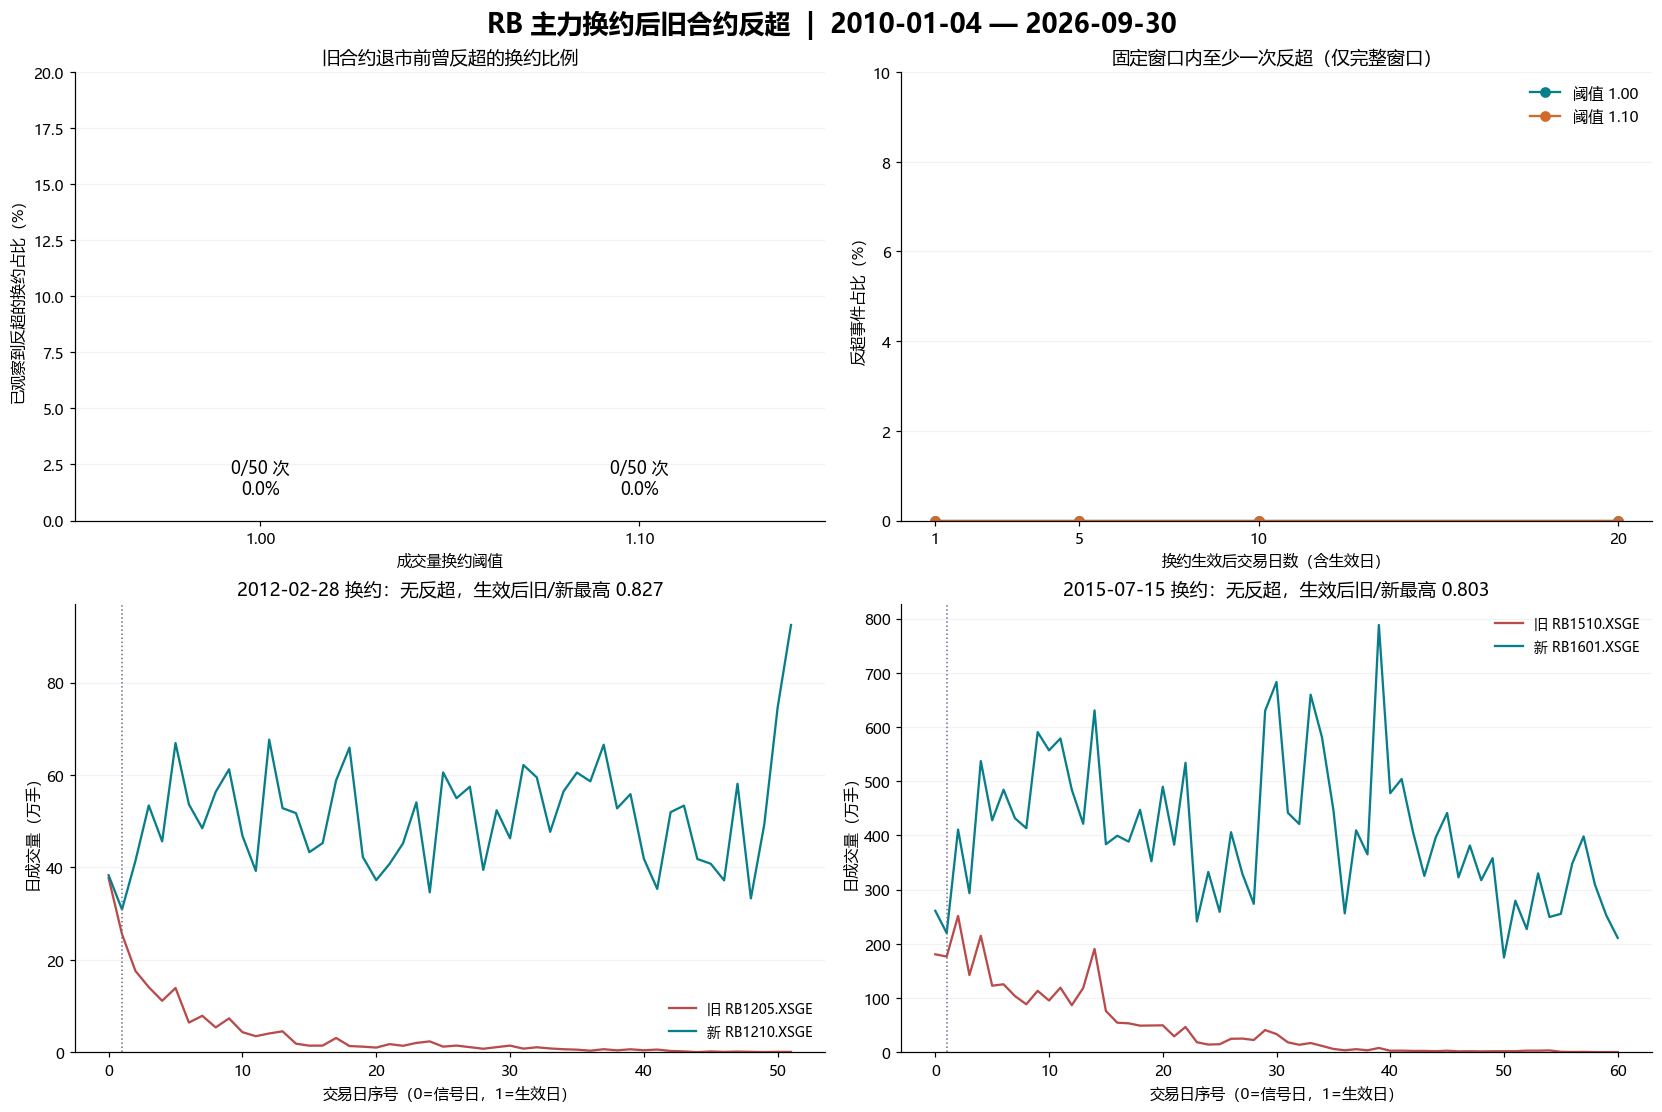

图形：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_13/testing_13_rb_roll_reversals.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), layout="constrained")
fig.suptitle(f"RB 主力换约后旧合约反超  |  {sample_start} — {sample_end}", fontsize=17, fontweight="bold")
ratio_labels = [f"{ratio:.2f}" for ratio in summary_df.index]
bars = axes[0, 0].bar(ratio_labels, summary_df["观察到反超比例（%）"], color=["#087e8b", "#d26a2c"])
for bar, (_, summary_row) in zip(bars, summary_df.iterrows()):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{int(summary_row['发生反超的换约次数'])}/{int(summary_row['阈值换约次数'])} 次\n{bar.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=11)
axes[0, 0].set(title="旧合约退市前曾反超的换约比例", xlabel="成交量换约阈值", ylabel="已观察到反超的换约占比（%）", ylim=(0, min(115, max(20, summary_df["观察到反超比例（%）"].max() + 16))))
for ratio, color in zip(ROLL_TRIGGER_RATIOS, ["#087e8b", "#d26a2c"]):
    ratio_window_df = window_summary_df.loc[window_summary_df["阈值"].eq(ratio)]
    axes[0, 1].plot(ratio_window_df["窗口交易日数"], ratio_window_df["窗口内反超比例（%）"], marker="o", color=color, label=f"阈值 {ratio:.2f}")
axes[0, 1].set(title="固定窗口内至少一次反超（仅完整窗口）", xlabel="换约生效后交易日数（含生效日）", ylabel="反超事件占比（%）", xticks=FOLLOWUP_WINDOWS, ylim=(0, max(10, window_summary_df["窗口内反超比例（%）"].max() + 5)))
axes[0, 1].legend(frameon=False)
example_events_df = experiment_events_df.sort_values(
    ["reversal_days", "max_old_new_volume_ratio", "roll_date"],
    ascending=[False, False, True],
).head(2)
for ax, event in zip(axes[1], example_events_df.itertuples(index=False)):
    example_daily_df = roll_pair_daily_df.loc[
        roll_pair_daily_df["roll_trigger_ratio"].eq(1.00)
        & roll_pair_daily_df["event_number"].eq(event.event_number)
    ]
    signal_daily_df = daily_df.loc[daily_df["trading_date"].eq(event.signal_date)].set_index("contract_code")
    x = np.r_[0, example_daily_df["followup_day"].to_numpy()]
    old_volume = np.r_[float(signal_daily_df.loc[event.old_contract_code, "volume"]), example_daily_df["old_volume"].to_numpy()] / 10000
    new_volume = np.r_[float(signal_daily_df.loc[event.new_contract_code, "volume"]), example_daily_df["new_volume"].to_numpy()] / 10000
    ax.plot(x, old_volume, color="#b94b4b", label=f"旧 {event.old_contract_code}")
    ax.plot(x, new_volume, color="#087e8b", label=f"新 {event.new_contract_code}")
    if (old_volume > new_volume).any():
        ax.fill_between(x, old_volume, new_volume, where=old_volume > new_volume, color="#b94b4b", alpha=0.22, label="旧量反超")
    ax.axvline(1, color="#667085", ls=":", lw=1)
    reversal_label = f"反超 {event.reversal_days} 天" if event.has_reversal else "无反超"
    ax.set(title=f"{event.roll_date} 换约：{reversal_label}，生效后旧/新最高 {event.max_old_new_volume_ratio:.3f}", xlabel="交易日序号（0=信号日，1=生效日）", ylabel="日成交量（万手）", ylim=(0, None))
    ax.legend(frameon=False, fontsize=9)
for ax in axes.flat:
    ax.grid(axis="y", alpha=0.16)
figure_path = output_dir / "testing_13_rb_roll_reversals.png"
if EXPORT_FILES:
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
if EXPORT_FILES:
    print(f"图形：{figure_path}")

## 7. 结论适用范围

统计对象是正式湖已保存的 RB 日线全历史，未覆盖湖起点以前的交易。成交量只在同一交易日的两个合约之间比较，保留来源原值。换约时间来自上一日信号；反超结果只用于事后评价，不反馈到当日主力选择。

1.10 能否减少反超，应同时看反超事件数、分母、窗口和样本末端状态；较少反超不能单独证明该阈值能提高策略收益或降低交易成本。本 Notebook 没有评估价格跳跃、滑点、持仓迁移成本，也没有寻找最优阈值。

若需核查某次换约，可在下面修改 `EVENT_NUMBER`，查看 1.00 阈值下固定合约对的全部日成交量。

算法边界检查包括严格大于、下一交易日生效、不回退、相等不算反超、零量可比较、缺失不填零、完整窗口分母和样本末端删失。1.10 的全历史主力映射已与 testing_10 的原函数逐行核对一致；反超结果另以旧／新合约日线直接按日期合并核对。

In [10]:
EVENT_NUMBER = int(reversed_roll_events_df["event_number"].iloc[0]) if not reversed_roll_events_df.empty else 1
selected_pair_daily_df = roll_pair_daily_df.loc[
    roll_pair_daily_df["roll_trigger_ratio"].eq(1.00)
    & roll_pair_daily_df["event_number"].eq(EVENT_NUMBER),
    ["trading_date", "followup_day", "old_contract_code", "new_contract_code",
     "old_volume", "new_volume", "is_reversal", "is_episode_start", "new_contract_still_main"],
]
with pd.option_context("display.max_rows", None):
    display(selected_pair_daily_df)

contract_code,trading_date,followup_day,old_contract_code,new_contract_code,old_volume,new_volume,is_reversal,is_episode_start,new_contract_still_main
0,2010-03-02,1,RB1005.XSGE,RB1010.XSGE,425640.0,850004.0,False,False,True
1,2010-03-03,2,RB1005.XSGE,RB1010.XSGE,234628.0,857462.0,False,False,True
2,2010-03-04,3,RB1005.XSGE,RB1010.XSGE,231868.0,1139868.0,False,False,True
3,2010-03-05,4,RB1005.XSGE,RB1010.XSGE,233628.0,972182.0,False,False,True
4,2010-03-08,5,RB1005.XSGE,RB1010.XSGE,268998.0,1078198.0,False,False,True
5,2010-03-09,6,RB1005.XSGE,RB1010.XSGE,152230.0,1233638.0,False,False,True
6,2010-03-10,7,RB1005.XSGE,RB1010.XSGE,182522.0,1473124.0,False,False,True
7,2010-03-11,8,RB1005.XSGE,RB1010.XSGE,145818.0,2179364.0,False,False,True
8,2010-03-12,9,RB1005.XSGE,RB1010.XSGE,85232.0,1492582.0,False,False,True
9,2010-03-15,10,RB1005.XSGE,RB1010.XSGE,136538.0,1417516.0,False,False,True
